<a href="https://colab.research.google.com/github/vanillaloki9306/Measles-and-Rubella-dataset-project/blob/main/Measles_and_Rubella_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [17]:
# Using Python
# Option 1: pydytuesday python library
# pip install pydytuesday
!pip install pandas numpy matplotlib countryinfo
import pandas as pd

 # import pydytuesday

import numpy as py

import matplotlib.pyplot as plt



from countryinfo import CountryInfo

from sklearn.feature_selection import SelectKBest
from sklearn import model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
import scipy.stats as stats

This is my data wrangling box. All the progress I made I put into this code block so I can click it once and have everything ready to go.

In [33]:
# datasets

#run this everytime

cases_month = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-06-24/cases_month.csv')
cases_year = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-06-24/cases_year.csv')

cases_month['region'] = cases_month['region'].replace({"EMR":"Eastern Mediterranean",
                                                       "EUR":"Europe",
                                                       "AFR":"Africa",
                                                       "AMR":"Americas",
                                                       "WPR":"Western Pacific",
                                                       "SEAR":"South East Asia"})

cases_month = cases_month.rename(columns = {"region":"Region",
                                            "year":"Year",
                                            "country":"Country",
                                            "month":"Month",
                                            "measles_suspect":"Measles Suspect",
                                            "measles_clinical":"Measles Clinical",
                                            "measles_epi_linked":"Measles EPI Linked",
                                            "measles_lab_confirmed":"Measles Lab Confirmed",
                                            "measles_total":"Measles Total",
                                            "rubella_clinical":"Rubella Clinical",
                                            "rubella_epi_linked":"Rubella EPI Linked",
                                            "rubella_lab_confirmed":"Rubella Lab Confirmed",
                                            "rubella_total":"Rubella Total",
                                            "discarded":"Discarded"})

cases_month['Total Month'] = (cases_month['Year'] - 2012) * 12 + cases_month['Month']
cases_month['Region Code'] = pd.factorize(cases_month['Region'])[0]
cases_month['iso3 Code'] = pd.factorize(cases_month['iso3'])[0]

def hemisphere(iso3):
    latitude = CountryInfo(iso3).latlng()[0]
    if latitude >= 0:
      return "Northern"
    else:
      return "Southern"

cases_month['Hemisphere'] = cases_month['iso3'].apply(hemisphere)

cases_north = cases_month[cases_month['Hemisphere'] == "Northern"]
cases_south = cases_month[cases_month['Hemisphere'] == "Southern"]

seasons_north = {12: "Winter", 1: "Winter", 2: "Winter",
                3: "Spring", 4:"Spring", 5:"Spring",
                6:"Summer", 7:"Summer", 8:"Summer",
                9:"Fall", 10:"Fall", 11:"Fall"}

seasons_south = {6: "Winter", 7: "Winter", 8: "Winter",
                9: "Spring", 10: "Spring", 11: "Spring",
                12: "Summer", 1: "Summer", 2: "Summer",
                3: "Fall", 4: "Fall", 5: "Fall"}

def season_checker(datarows):
    if datarows['Hemisphere'] == "Northern":
      return seasons_north[datarows['Month']]
    elif datarows['Hemisphere'] == 'Southern':
      return seasons_south[datarows['Month']]

cases_month['Season'] = cases_month.apply(season_checker, axis =1 )

cases_measles = pd.DataFrame({'Region': cases_month['Region'],
                               'Region Code': cases_month['Region Code'],
                               'iso3 Code': cases_month['iso3 Code'],
                               'Year': cases_month["Year"],
                               'Total Month': cases_month['Total Month'],
                               'Season': pd.factorize(cases_month['Season'])[0],
                               'Log Total': py.log1p(cases_month['Measles Total']),
                               'Hemisphere': pd.factorize(cases_month['Hemisphere'])[0]})
cases_measles = cases_measles.dropna()

cases_rubella = pd.DataFrame({'Region': cases_month['Region'],
                               'Region Code': cases_month['Region Code'],
                               'iso3 Code': cases_month['iso3 Code'],
                               'Year': cases_month["Year"],
                               'Total Month': cases_month['Total Month'],
                               'Season': pd.factorize(cases_month['Season'])[0],
                               'Log Total': py.log1p(cases_month['Rubella Total']),
                               'Hemisphere': pd.factorize(cases_month['Hemisphere'])[0]})
cases_rubella = cases_rubella.dropna()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [23]:
# This part is primarly for graphing

rubella_north = pd.DataFrame({'Region': cases_north['Region'],
                               'Country': cases_north['Country'],
                               'iso3': cases_north['iso3'],
                               'Year': cases_north["Year"],
                               'Month': cases_north['Month'],
                               'Season': cases_north['Month'].map(seasons_north),
                               'Clinical': cases_north["Rubella Clinical"],
                               'Epi Linked': cases_north['Rubella EPI Linked'],
                               'Lab Confirmed': cases_north['Rubella Lab Confirmed'],
                               'Total': cases_north['Rubella Total']})
rubella_north = rubella_north.dropna()


rubella_south = pd.DataFrame({'Region': cases_south['Region'],
                               'Country': cases_south['Country'],
                               'iso3': cases_south['iso3'],
                               'Year': cases_south["Year"],
                               'Month': cases_south['Month'],
                               'Season': cases_south['Month'].map(seasons_south),
                               'Clinical': cases_south["Rubella Clinical"],
                               'Epi Linked': cases_south['Rubella EPI Linked'],
                               'Lab Confirmed': cases_south['Rubella Lab Confirmed'],
                               'Total': cases_south['Rubella Total']})
rubella_south = rubella_south.dropna()

measles_south = pd.DataFrame({'Region': cases_south['Region'],
                               'Country': cases_south['Country'],
                               'iso3': cases_south['iso3'],
                               'Year': cases_south["Year"],
                               'Month': cases_south['Month'],
                               'Season': cases_south['Month'].map(seasons_south),
                               'Suspect': cases_south['Measles Suspect'],
                               'Clinical': cases_south["Measles Clinical"],
                               'Epi Linked': cases_south['Measles EPI Linked'],
                               'Lab Confirmed': cases_south['Measles Lab Confirmed'],
                               'Total': cases_south['Measles Total'],
                               'Discarded': cases_south['Discarded']})
measles_south = measles_south.dropna()

measles_north = pd.DataFrame({'Region': cases_north['Region'],
                               'Country': cases_north['Country'],
                               'iso3': cases_north['iso3'],
                               'Year': cases_north["Year"],
                               'Month': cases_north['Month'],
                               'Season': cases_north['Month'].map(seasons_north),
                               'Suspect': cases_north['Measles Suspect'],
                               'Clinical': cases_north["Measles Clinical"],
                               'Epi Linked': cases_north['Measles EPI Linked'],
                               'Lab Confirmed': cases_north['Measles Lab Confirmed'],
                               'Total': cases_north['Measles Total'],
                               'Discarded': cases_north['Discarded']})
measles_north = measles_north.dropna()


,Region,Country,iso3,Year,Month,Measles Suspect,Measles Clinical,Measles EPI Linked,Measles Lab Confirmed,Measles Total,Rubella Clinical,Rubella EPI Linked,Rubella Lab Confirmed,Rubella Total,Discarded,Region Code,iso3 Code,Hemisphere
0,Africa,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0,0,0,Northern
1,Africa,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0,0,0,Northern
2,Africa,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,0,0,Northern
3,Africa,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0,0,0,Northern
4,Africa,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0,0,0,Northern
5,Africa,Algeria,DZA,2012,6,10.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,10.0,0,0,Northern
6,Africa,Algeria,DZA,2012,7,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,0,0,Northern
7,Africa,Algeria,DZA,2012,10,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,0.0,0,0,Northern
8,Africa,Algeria,DZA,2012,11,3.0,3.0,0.0,0.0,3.0,NaN,NaN,NaN,NaN,0.0,0,0,Northern
9,Africa,Algeria,DZA,2012,12,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,0,0,Northern


# Data wrangling


In [ ]:
cases_month.tail(50)

,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded
22730,WPR,Viet Nam,VNM,2021,1,45.0,17.0,0.0,1.0,18.0,NaN,NaN,NaN,NaN,27.0
22731,WPR,Viet Nam,VNM,2021,2,10.0,4.0,0.0,1.0,5.0,NaN,NaN,NaN,NaN,5.0
22732,WPR,Viet Nam,VNM,2021,3,63.0,23.0,0.0,10.0,33.0,NaN,NaN,NaN,NaN,30.0
22733,WPR,Viet Nam,VNM,2021,4,79.0,27.0,0.0,12.0,39.0,0.0,0.0,3.0,3.0,40.0
22734,WPR,Viet Nam,VNM,2021,5,38.0,15.0,0.0,8.0,23.0,0.0,0.0,1.0,1.0,15.0
22735,WPR,Viet Nam,VNM,2021,6,37.0,21.0,0.0,1.0,22.0,1.0,0.0,0.0,1.0,15.0
22736,WPR,Viet Nam,VNM,2021,7,16.0,7.0,0.0,0.0,7.0,NaN,NaN,NaN,NaN,9.0
22737,WPR,Viet Nam,VNM,2021,8,15.0,11.0,0.0,0.0,11.0,NaN,NaN,NaN,NaN,4.0
22738,WPR,Viet Nam,VNM,2021,9,13.0,8.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,5.0
22739,WPR,Viet Nam,VNM,2021,10,17.0,7.0,0.0,0.0,7.0,0.0,0.0,1.0,1.0,10.0


In [ ]:
cases_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22780 entries, 0 to 22779
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   region                 22780 non-null  object 
 1   country                22780 non-null  object 
 2   iso3                   22780 non-null  object 
 3   year                   22780 non-null  int64  
 4   month                  22780 non-null  int64  
 5   measles_suspect        22632 non-null  float64
 6   measles_clinical       22632 non-null  float64
 7   measles_epi_linked     22632 non-null  float64
 8   measles_lab_confirmed  22632 non-null  float64
 9   measles_total          22632 non-null  float64
 10  rubella_clinical       7811 non-null   float64
 11  rubella_epi_linked     7811 non-null   float64
 12  rubella_lab_confirmed  7811 non-null   float64
 13  rubella_total          7811 non-null   float64
 14  discarded              22632 non-null  float64
dtypes:

In [ ]:
cases_month.describe()

,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded
count,22780.000000,22780.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,7811.000000,7811.000000,7811.000000,7811.000000,22632.000000
mean,2018.253600,6.293547,235.265376,50.708687,38.939069,47.029251,136.677006,19.815901,4.344130,20.066317,44.226347,112.301653
std,3.815709,3.461782,1203.690535,408.194314,748.287331,275.099951,969.226508,283.628969,60.004873,145.382545,335.242009,524.224152
min,2012.000000,1.000000,0.000000,-204.000000,0.000000,0.000000,-195.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,2018.000000,6.000000,23.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,4.000000,14.000000
75%,2022.000000,9.000000,110.000000,2.000000,0.000000,14.000000,29.000000,0.000000,0.000000,11.000000,15.000000,60.000000
max,2025.000000,12.000000,68051.000000,12730.000000,67728.000000,9936.000000,67929.000000,10856.000000,2476.000000,7039.000000,10856.000000,16443.000000


In [ ]:
cases_month.shape

(22780, 15)

In [ ]:
cases_month = cases_month.drop_duplicates()
cases_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22780 entries, 0 to 22779
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   region                 22780 non-null  object 
 1   country                22780 non-null  object 
 2   iso3                   22780 non-null  object 
 3   year                   22780 non-null  int64  
 4   month                  22780 non-null  int64  
 5   measles_suspect        22632 non-null  float64
 6   measles_clinical       22632 non-null  float64
 7   measles_epi_linked     22632 non-null  float64
 8   measles_lab_confirmed  22632 non-null  float64
 9   measles_total          22632 non-null  float64
 10  rubella_clinical       7811 non-null   float64
 11  rubella_epi_linked     7811 non-null   float64
 12  rubella_lab_confirmed  7811 non-null   float64
 13  rubella_total          7811 non-null   float64
 14  discarded              22632 non-null  float64
dtypes:

In [ ]:
cases_month['discarded']

,discarded
0,0.0
1,0.0
2,0.0
3,2.0
4,3.0
...,...
22775,48.0
22776,75.0
22777,60.0
22778,25.0


In [ ]:
cases_month[['rubella_clinical', 'rubella_epi_linked', 'rubella_lab_confirmed', 'rubella_total']].head(50)

,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,0.0,0.0,1.0,1.0
4,0.0,0.0,3.0,3.0
5,0.0,0.0,8.0,8.0
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,0.0,0.0,1.0,1.0


In [ ]:

cases_month['year'].value_counts()


cases_month['region'] = cases_month['region'].replace({"EMR":"Eastern Mediterranean", "EUR":"Europe", "AFR":"Africa", "AMR":"Americas", "WPR":"Western Pacific", "SEAR":"South East Asia"})
cases_month['region'].value_counts()

,count
region,
Europe,6409
Africa,6241
Eastern Mediterranean,3101
Americas,2986
Western Pacific,2404
South East Asia,1639


There isn't any missing data for Measles cases, however, the Rubella cases do have about 15000 missing points of data.
I'm going to categorize the data by splitting it into two separate datasets, organized where the country is the row, and the total cases organized into 4-month averages (for both Measles and Rubella) would be the columns.
This way I can compare the country to their by thirds progress.
The reason why I chose 4 month average is because it would require 12 straight missing points of data to not have one.


I'm going to begin by dropping all the rows where both rubella and measles aren't included.

In [ ]:
cases_month = cases_month.dropna(subset = ['measles_total', 'rubella_total'], how='all')
cases_measles = pd.DataFrame({'Region': cases_month['region'],
                               'Country': cases_month['country'],
                               'iso3': cases_month['iso3'],
                               'Year': cases_month["year"],
                               'Month': cases_month['month'],
                               'Suspect': cases_month['measles_suspect'],
                               'Clinical': cases_month["measles_clinical"],
                               'Epi Linked': cases_month['measles_epi_linked'],
                               'Lab Confirmed': cases_month['measles_lab_confirmed'],
                               'Total': cases_month['measles_total']})
cases_measles

,Region,Country,iso3,Year,Month,Suspect,Clinical,Epi Linked,Lab Confirmed,Total
0,Africa,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0
1,Africa,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0
2,Africa,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0
3,Africa,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0
4,Africa,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...
22775,Western Pacific,Viet Nam,VNM,2024,10,379.0,19.0,56.0,256.0,331.0
22776,Western Pacific,Viet Nam,VNM,2024,11,584.0,37.0,125.0,347.0,509.0
22777,Western Pacific,Viet Nam,VNM,2024,12,588.0,56.0,134.0,338.0,528.0
22778,Western Pacific,Viet Nam,VNM,2025,1,156.0,7.0,0.0,124.0,131.0


In [ ]:
cases_rubella = pd.DataFrame({'Region': cases_month['region'],
                               'Country': cases_month['country'],
                               'iso3': cases_month['iso3'],
                               'Year': cases_month["year"],
                               'Month': cases_month['month'],
                               'Clinical': cases_month["rubella_clinical"],
                               'Epi Linked': cases_month['rubella_epi_linked'],
                               'Lab Confirmed': cases_month['rubella_lab_confirmed'],
                               'Total': cases_month['rubella_total']})
cases_rubella = cases_rubella.dropna()
cases_rubella.info()
cases_rubella.shape

<class 'pandas.core.frame.DataFrame'>
Index: 7811 entries, 3 to 22777
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         7811 non-null   object 
 1   Country        7811 non-null   object 
 2   iso3           7811 non-null   object 
 3   Year           7811 non-null   int64  
 4   Month          7811 non-null   int64  
 5   Clinical       7811 non-null   float64
 6   Epi Linked     7811 non-null   float64
 7   Lab Confirmed  7811 non-null   float64
 8   Total          7811 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 610.2+ KB


(7811, 9)

Now that I got two different dataframes, I'm gonna visualize it.

This first one is visualizing Rubella cases

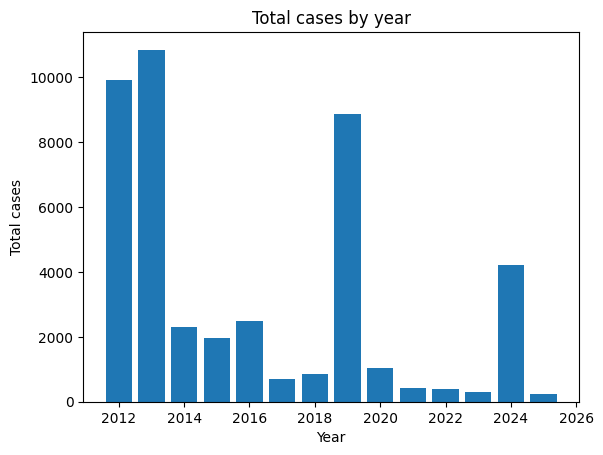

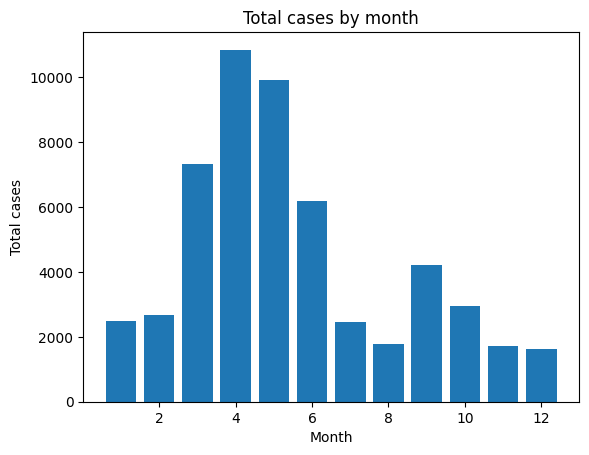

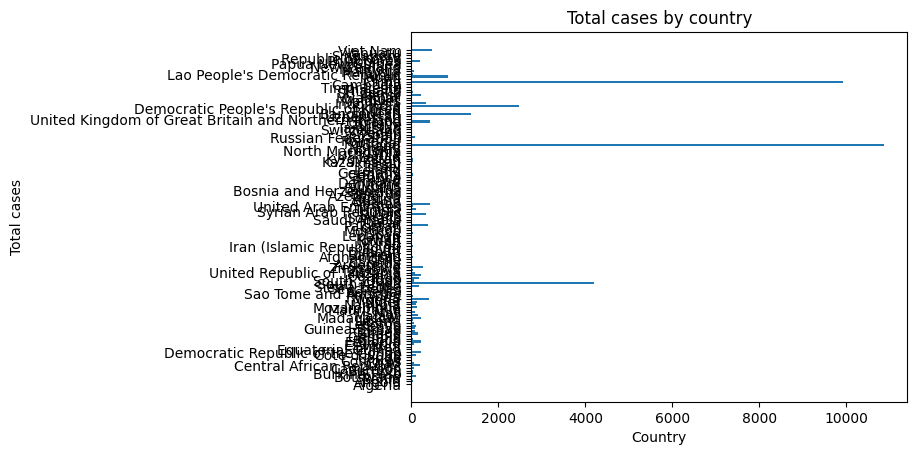

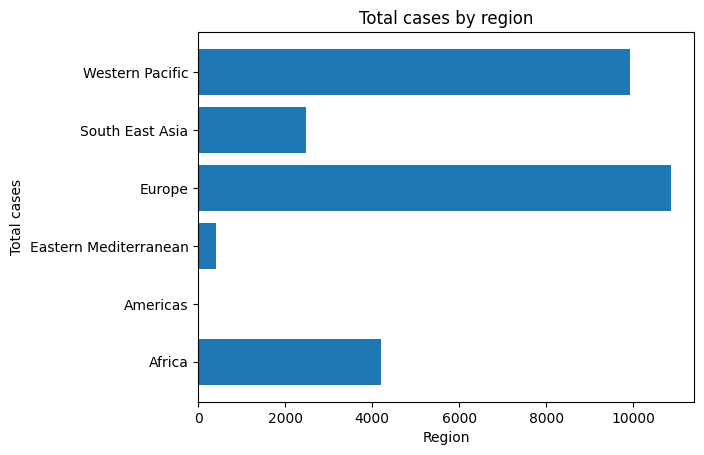

In [ ]:
vars_x = cases_rubella['Year']
vars_y = cases_rubella['Total']

plt.bar(vars_x, vars_y)
plt.title("Total cases by year")
plt.xlabel("Year")
plt.ylabel("Total cases")
plt.show()


vars_x = cases_rubella['Month']
vars_y = cases_rubella['Total']

plt.bar(vars_x, vars_y)
plt.title("Total cases by month")
plt.xlabel("Month")
plt.ylabel("Total cases")
plt.show()



vars_x = cases_rubella['Country']
vars_y = cases_rubella['Total']

plt.barh(vars_x, vars_y)
plt.title("Total cases by country")
plt.xlabel("Country")
plt.ylabel("Total cases")
plt.show()


vars_x = cases_rubella['Region']
vars_y = cases_rubella['Total']

plt.barh(vars_x, vars_y)
plt.title("Total cases by region")
plt.xlabel("Region")
plt.ylabel("Total cases")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

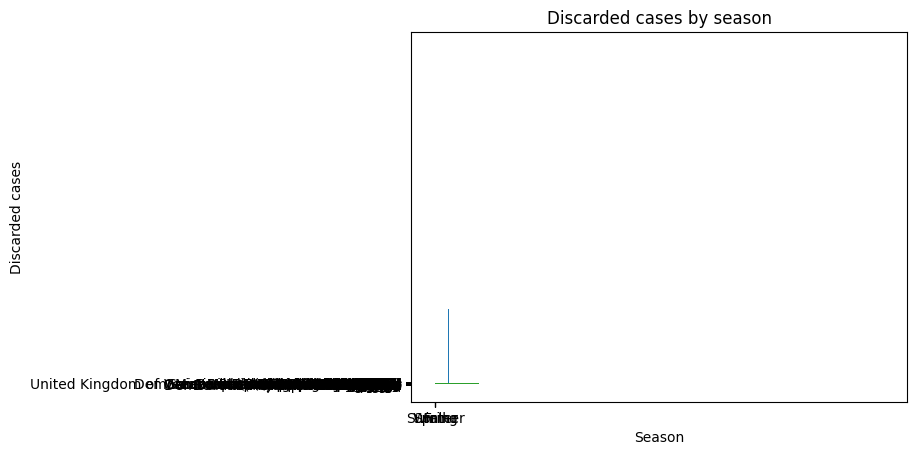

In [ ]:
vars_x = cases_measles['Year']
vars_y = cases_measles['Total']

plt.bar(vars_x, vars_y)
plt.title("Total cases by year")
plt.xlabel("Year")
plt.ylabel("Total cases")
# plt.show()


vars_x = cases_measles['Month']


plt.bar(vars_x, vars_y)
plt.title("Total cases by month")
plt.xlabel("Month")
plt.ylabel("Total cases")
# plt.show()



vars_x = cases_measles['Country']


plt.barh(vars_x, vars_y)
plt.title("Total cases by country")
plt.xlabel("Country")
plt.ylabel("Total cases")
# plt.show()


vars_x = cases_measles['Region']


plt.barh(vars_x, vars_y)
plt.title("Total cases by region")
plt.xlabel("Region")
plt.ylabel("Total cases")
# plt.show()


vars_x = cases_measles['Season']
vars_y = cases_measles['Discarded']

plt.bar(vars_x, vars_y)
plt.title("Discarded cases by season")
plt.xlabel("Season")
plt.ylabel("Discarded cases")
plt.show

I want to split the data by season as well. For this one, I'm not going to separate by measles/rubella



In [ ]:
seasonal_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4:"Spring", 5:"Spring", 6:"Summer", 7:"Summer", 8:"Summer", 9:"Fall", 10:"Fall", 11:"Fall"}

cases_month['Season'] = cases_month['month'].map(seasonal_map)
Seasons = cases_month.groupby("Season")['year']
cases_month

,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded,Season
0,Africa,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0,Winter
1,Africa,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0,Winter
2,Africa,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,Spring
3,Africa,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0,Spring
4,Africa,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22775,Western Pacific,Viet Nam,VNM,2024,10,379.0,19.0,56.0,256.0,331.0,5.0,0.0,5.0,10.0,48.0,Fall
22776,Western Pacific,Viet Nam,VNM,2024,11,584.0,37.0,125.0,347.0,509.0,0.0,0.0,1.0,1.0,75.0,Fall
22777,Western Pacific,Viet Nam,VNM,2024,12,588.0,56.0,134.0,338.0,528.0,0.0,0.0,1.0,1.0,60.0,Winter
22778,Western Pacific,Viet Nam,VNM,2025,1,156.0,7.0,0.0,124.0,131.0,NaN,NaN,NaN,NaN,25.0,Winter


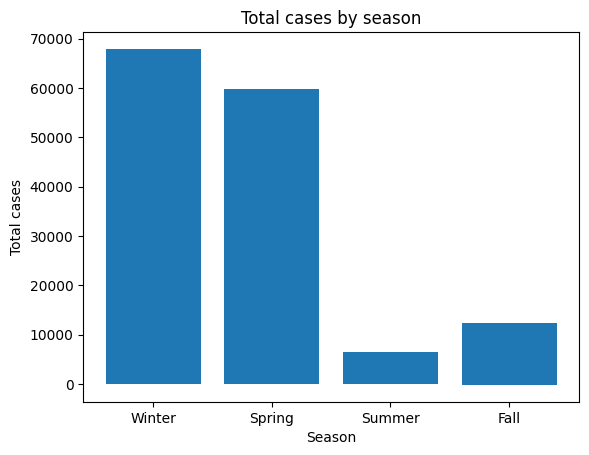

<bound method NDFrame.describe of                 region   country iso3  year  month  measles_suspect  \
0               Africa   Algeria  DZA  2012      1              8.0   
1               Africa   Algeria  DZA  2012      2             10.0   
2               Africa   Algeria  DZA  2012      3             17.0   
3               Africa   Algeria  DZA  2012      4              7.0   
4               Africa   Algeria  DZA  2012      5             14.0   
...                ...       ...  ...   ...    ...              ...   
22775  Western Pacific  Viet Nam  VNM  2024     10            379.0   
22776  Western Pacific  Viet Nam  VNM  2024     11            584.0   
22777  Western Pacific  Viet Nam  VNM  2024     12            588.0   
22778  Western Pacific  Viet Nam  VNM  2025      1            156.0   
22779  Western Pacific  Viet Nam  VNM  2025      2             22.0   

       measles_clinical  measles_epi_linked  measles_lab_confirmed  \
0                   6.0                 0.0                    2.0   
1                  10.0                 0.0                    0.0   
2                  17.0                 0.0                    0.0   
3                   5.0                 0.0                    0.0   
4                  11.0                 0.0                    0.0   
...                 ...                 ...                    ...   
22775              19.0                56.0                  256.0   
22776              37.0               125.0                  347.0   
22777              56.0               134.0                  338.0   
22778               7.0                 0.0                  124.0   
22779               0.0                 0.0                   20.0   

       measles_total  rubella_clinical  rubella_epi_linked  \
0                8.0               NaN                 NaN   
1               10.0               NaN                 NaN   
2               17.0               NaN                 NaN   
3                5.0               0.0                 0.0   
4               11.0               0.0                 0.0   
...              ...               ...                 ...   
22775          331.0               5.0                 0.0   
22776          509.0               0.0                 0.0   
22777          528.0               0.0                 0.0   
22778          131.0               NaN                 NaN   
22779           20.0               NaN                 NaN   

       rubella_lab_confirmed  rubella_total  discarded  Season  
0                        NaN            NaN        0.0  Winter  
1                        NaN            NaN        0.0  Winter  
2                        NaN            NaN        0.0  Spring  
3                        1.0            1.0        2.0  Spring  
4                        3.0            3.0        3.0  Spring  
...                      ...            ...        ...     ...  
22775                    5.0           10.0       48.0    Fall  
22776                    1.0            1.0       75.0    Fall  
22777                    1.0            1.0       60.0  Winter  
22778                    NaN            NaN       25.0  Winter  
22779                    NaN            NaN        2.0  Winter  

[22780 rows x 16 columns]>

In [ ]:
vars_x = cases_month['Season']
vars_y = cases_month['measles_total']


plt.bar(vars_x, vars_y)
plt.title("Total cases by season")
plt.xlabel("Season")
plt.ylabel("Total cases")
plt.show()


In [ ]:
from countryinfo import CountryInfo

def hemisphere(iso3):
    latitude = CountryInfo(iso3).latlng()[0]
    if latitude >= 0:
      return "Northern"
    else:
      return "Southern"

cases_measles['Hemisphere'] = cases_measles['iso3'].apply(hemisphere)
cases_measles.tail(200)

,Region,Country,iso3,Year,Month,Season,Suspect,Clinical,Epi Linked,Lab Confirmed,Total,Discarded,Hemisphere
22580,Western Pacific,Solomon Islands,SLB,2021,12,Winter,0.0,0.0,0.0,0.0,0.0,0.0,Southern
22581,Western Pacific,Solomon Islands,SLB,2022,12,Winter,0.0,0.0,0.0,0.0,0.0,0.0,Southern
22582,Western Pacific,Solomon Islands,SLB,2023,5,Spring,1.0,0.0,0.0,0.0,0.0,1.0,Southern
22583,Western Pacific,Solomon Islands,SLB,2023,6,Summer,1.0,0.0,0.0,0.0,0.0,1.0,Southern
22584,Western Pacific,Solomon Islands,SLB,2023,9,Fall,7.0,0.0,0.0,0.0,0.0,7.0,Southern
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22775,Western Pacific,Viet Nam,VNM,2024,10,Fall,379.0,19.0,56.0,256.0,331.0,48.0,Northern
22776,Western Pacific,Viet Nam,VNM,2024,11,Fall,584.0,37.0,125.0,347.0,509.0,75.0,Northern
22777,Western Pacific,Viet Nam,VNM,2024,12,Winter,588.0,56.0,134.0,338.0,528.0,60.0,Northern
22778,Western Pacific,Viet Nam,VNM,2025,1,Winter,156.0,7.0,0.0,124.0,131.0,25.0,Northern


In [ ]:
measles_south

,Region,Country,iso3,Year,Month,Season,Suspect,Clinical,Epi Linked,Lab Confirmed,Total,Discarded
123,Africa,Angola,AGO,2012,1,Summer,396.0,228.0,125.0,20.0,373.0,23.0
124,Africa,Angola,AGO,2012,2,Summer,313.0,210.0,53.0,28.0,291.0,22.0
125,Africa,Angola,AGO,2012,3,Fall,401.0,282.0,63.0,36.0,381.0,20.0
126,Africa,Angola,AGO,2012,4,Fall,397.0,294.0,73.0,24.0,391.0,6.0
127,Africa,Angola,AGO,2012,5,Fall,563.0,318.0,182.0,48.0,548.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22617,Western Pacific,Vanuatu,VUT,2015,6,Winter,17.0,0.0,0.0,0.0,0.0,17.0
22618,Western Pacific,Vanuatu,VUT,2015,8,Winter,1.0,0.0,0.0,0.0,0.0,1.0
22619,Western Pacific,Vanuatu,VUT,2015,9,Spring,10.0,0.0,0.0,3.0,3.0,7.0
22620,Western Pacific,Vanuatu,VUT,2016,5,Fall,7.0,0.0,0.0,0.0,0.0,7.0


In [ ]:
measles_north

,Region,Country,iso3,Year,Month,Season,Suspect,Clinical,Epi Linked,Lab Confirmed,Total,Discarded
0,Africa,Algeria,DZA,2012,1,Winter,8.0,6.0,0.0,2.0,8.0,0.0
1,Africa,Algeria,DZA,2012,2,Winter,10.0,10.0,0.0,0.0,10.0,0.0
2,Africa,Algeria,DZA,2012,3,Spring,17.0,17.0,0.0,0.0,17.0,0.0
3,Africa,Algeria,DZA,2012,4,Spring,7.0,5.0,0.0,0.0,5.0,2.0
4,Africa,Algeria,DZA,2012,5,Spring,14.0,11.0,0.0,0.0,11.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22775,Western Pacific,Viet Nam,VNM,2024,10,Fall,379.0,19.0,56.0,256.0,331.0,48.0
22776,Western Pacific,Viet Nam,VNM,2024,11,Fall,584.0,37.0,125.0,347.0,509.0,75.0
22777,Western Pacific,Viet Nam,VNM,2024,12,Winter,588.0,56.0,134.0,338.0,528.0,60.0
22778,Western Pacific,Viet Nam,VNM,2025,1,Winter,156.0,7.0,0.0,124.0,131.0,25.0


In [ ]:
rubella_south

,Region,Country,iso3,Year,Month,Season,Clinical,Epi Linked,Lab Confirmed,Total
123,Africa,Angola,AGO,2012,1,Summer,0.0,0.0,4.0,4.0
124,Africa,Angola,AGO,2012,2,Summer,0.0,0.0,1.0,1.0
125,Africa,Angola,AGO,2012,3,Fall,0.0,0.0,1.0,1.0
126,Africa,Angola,AGO,2012,4,Fall,0.0,0.0,4.0,4.0
127,Africa,Angola,AGO,2012,5,Fall,0.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...
22064,Western Pacific,Papua New Guinea,PNG,2022,2,Summer,0.0,0.0,1.0,1.0
22066,Western Pacific,Papua New Guinea,PNG,2022,4,Fall,0.0,0.0,1.0,1.0
22069,Western Pacific,Papua New Guinea,PNG,2022,7,Winter,0.0,0.0,1.0,1.0
22609,Western Pacific,Vanuatu,VUT,2014,9,Spring,1.0,0.0,0.0,1.0


In [ ]:
rubella_north

,Region,Country,iso3,Year,Month,Season,Clinical,Epi Linked,Lab Confirmed,Total
3,Africa,Algeria,DZA,2012,4,Spring,0.0,0.0,1.0,1.0
4,Africa,Algeria,DZA,2012,5,Spring,0.0,0.0,3.0,3.0
5,Africa,Algeria,DZA,2012,6,Summer,0.0,0.0,8.0,8.0
9,Africa,Algeria,DZA,2012,12,Winter,0.0,0.0,1.0,1.0
10,Africa,Algeria,DZA,2013,1,Winter,0.0,0.0,22.0,22.0
...,...,...,...,...,...,...,...,...,...,...
22771,Western Pacific,Viet Nam,VNM,2024,6,Summer,2.0,0.0,0.0,2.0
22773,Western Pacific,Viet Nam,VNM,2024,8,Summer,0.0,0.0,1.0,1.0
22775,Western Pacific,Viet Nam,VNM,2024,10,Fall,5.0,0.0,5.0,10.0
22776,Western Pacific,Viet Nam,VNM,2024,11,Fall,0.0,0.0,1.0,1.0


# Revised graphs

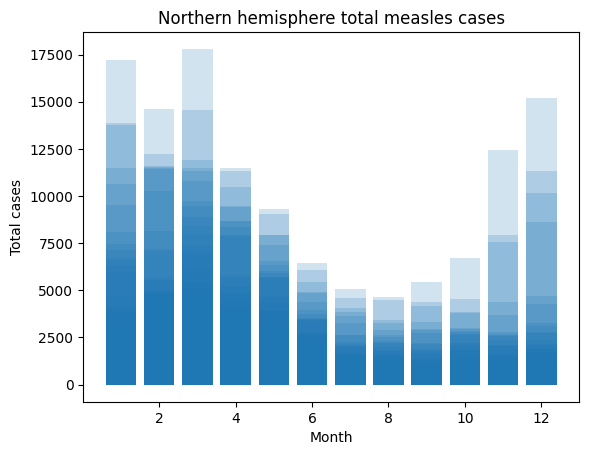

In [ ]:
vars_x = measles_north['Month']
vars_y = measles_north['Total']

plt.bar(vars_x, vars_y, alpha = 0.2)
plt.title("Northern hemisphere total measles cases")
plt.xlabel("Month")
plt.ylabel("Total cases")
plt.show()

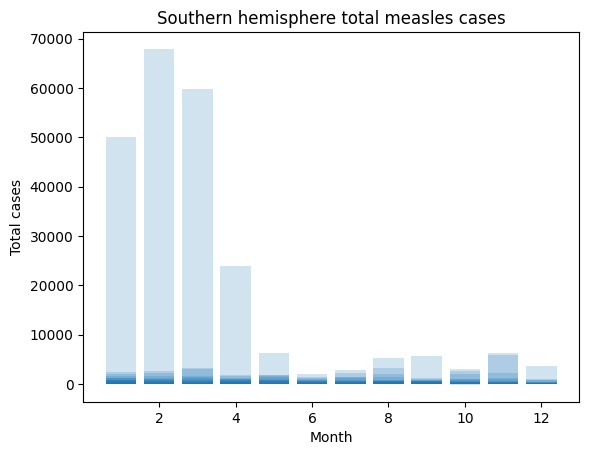

In [ ]:
vars_x = measles_south['Month']
vars_y = measles_south['Total']

plt.bar(vars_x, vars_y, alpha = 0.2)
plt.title("Southern hemisphere total measles cases")
plt.xlabel("Month")
plt.ylabel("Total cases")
plt.show()

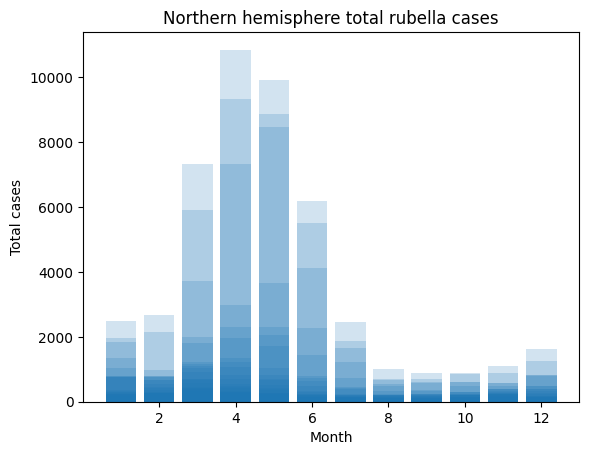

In [ ]:
vars_x = rubella_north['Month']
vars_y = rubella_north['Total']

plt.bar(vars_x, vars_y, alpha = 0.2)
plt.title("Northern hemisphere total rubella cases")
plt.xlabel("Month")
plt.ylabel("Total cases")
plt.show()

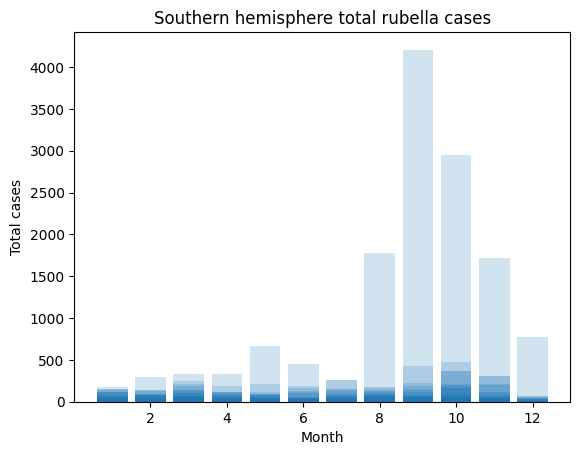

In [ ]:
vars_x = rubella_south['Month']
vars_y = rubella_south['Total']

plt.bar(vars_x, vars_y, alpha=0.2)
plt.title("Southern hemisphere total rubella cases")
plt.xlabel("Month")
plt.ylabel("Total cases")
plt.show()

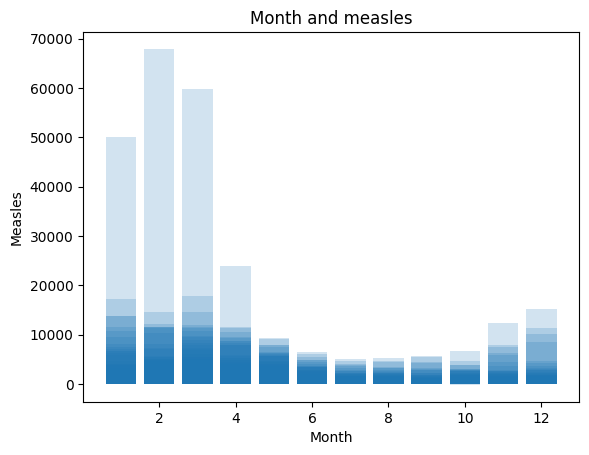

In [ ]:
vars_x = cases_month['Month']
vars_y = cases_month['Measles Total']

plt.bar(vars_x, vars_y, alpha = 0.2)
plt.title("Month and measles")
plt.xlabel("Month")
plt.ylabel("Measles")

plt.show()

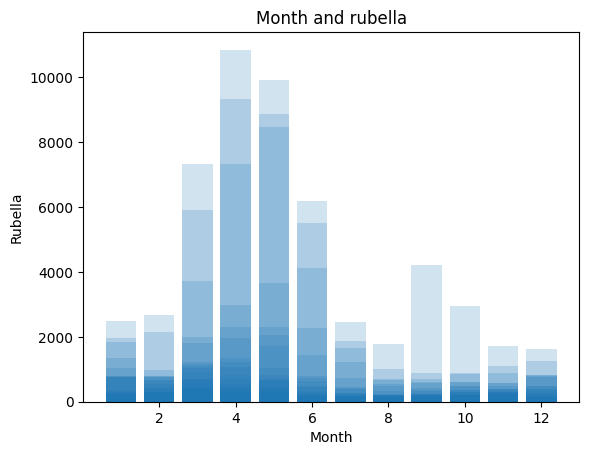

In [ ]:
vars_x = cases_month['Month']
vars_y = cases_month['Rubella Total']

plt.bar(vars_x, vars_y, alpha = 0.2)
plt.title("Month and rubella")
plt.xlabel("Month")
plt.ylabel("Rubella")

plt.show()

First try

# First try at fitting data

Hypothesis:
There is no correlation between time of year and measles cases. ∇
Hypothesis 2:
There is no correlation between regional conditions and measles cases.

Final hypothesis:
Regional factors are a better predictor of future measles cases than time of year.

In [34]:


x = cases_measles[['Region Code', 'iso3 Code', "Hemisphere"]]
y = cases_measles['Log Total']

X_train, X_test, y_train, y_test = model_selection.train_test_split(x, y, test_size = 0.2, random_state = 42)

model = RandomForestRegressor()


model.fit(X_train, y_train)

predictions1 = model.predict(X_test)

print(predictions1)

x2 = cases_measles[['Total Month', 'Season']]

# The month feature still has issues because the model treats December as 12 times greater than Janurary. Even though January is also next to December. I think I will get rid of the year and month distinction entirely and calculate the whole thing from start to finish with just months.
# E.g., Instead of year 3 month 3, I have it at month 39
y2 = cases_measles['Log Total']
# There is still drastic variance between different locations with different population sizes. I believe it is hurting the model because a country with 100,000 population is completely overshadowed by 100,000,000 population.
# I found that Numpy has a log feature that I can use

X_train2, X_test2, y_train2, y_test2 = model_selection.train_test_split(x2, y2, test_size = 0.2, random_state = 42)

model2 = RandomForestRegressor()


model2.fit(X_train2, y_train2)

predictions2 = model2.predict(X_test2)

print(predictions2)

mse1 = mean_squared_error(y_test, predictions1)
r2_1 = r2_score(y_test, predictions1)

mse2 = mean_squared_error(y_test2, predictions2)
r2_2 = r2_score(y_test2, predictions2)

print(f"Region mean squared error: {mse1}")
print(f"Region R2: {r2_1}")
print(f"Month mean squared error: {mse2}")
print(f"Month R2: {r2_2}")

# I have to figure out how to convert iso3 to a float
  # I searched it up and found pd.factorize
# I believe that there are country specific things that would make the data more accurate

[0.         0.         1.12218688 ... 0.65669882 0.0580893  0.36861123]
[2.78619407 2.54020099 2.16045777 ... 1.76280745 1.68363964 1.37829532]
Region mean squared error: 1.8989456654214178
Region R2: 0.5843341804761677
Month mean squared error: 4.433136394932961
Month R2: 0.02961769458959207
